In [1]:
from  sklearn.tree  import DecisionTreeClassifier,DecisionTreeRegressor

from  sklearn.ensemble   import ExtraTreesClassifier
from  sklearn.ensemble   import RandomForestClassifier,RandomForestRegressor
from  sklearn.ensemble  import BaggingClassifier
from  sklearn.ensemble import  AdaBoostClassifier
from  sklearn.ensemble import  GradientBoostingRegressor,GradientBoostingClassifier
from  sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingRegressor, StackingClassifier

from  sklearn.linear_model  import  LogisticRegression,LinearRegression
from  sklearn.svm  import  SVC,SVR
from  sklearn.neighbors  import KNeighborsClassifier 

from sklearn.datasets import make_moons  #  Classifier ucun 
from sklearn.datasets import load_iris     
from sklearn.datasets import fetch_openml  #  mnist ucun 
from sklearn.datasets import make_regression # Reqressiya ucun
from sklearn.datasets import load_diabetes  # Reqressiya ucun



import  matplotlib.pyplot  as plt
import  numpy as np
import  pandas as pd
import  time

from  sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV


from sklearn.metrics import accuracy_score, log_loss,mean_squared_error, mean_absolute_error, r2_score



## Voting Classifiers

In [3]:

X, y = make_moons(n_samples=10000, noise=0.2, random_state=42)

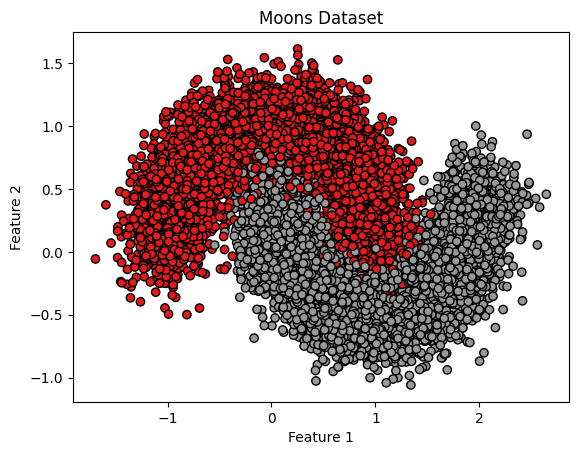

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1, edgecolor='k')
plt.title("Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [5]:
len(X)

10000

In [6]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=750, random_state=42)


##  HARD VOTING

In [221]:
log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC()

voting_clf = VotingClassifier(
    estimators=[('lr', log_clf ), 
                ('rf', rnd_clf ),
                ('svc', svm_clf )],
    voting='hard'
)

voting_clf.fit(X_train , y_train)

for  clf in (log_clf , rnd_clf , svm_clf, voting_clf):
    clf.fit(X_train , y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__,'----------',accuracy_score(y_test, y_pred))


c:\Users\USER\envs\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\USER\envs\env\Lib\site-packages\sklearn\ensemble\_forest.py:830: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\USER\envs\env\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\USER\envs\env\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression 

LogisticRegression ---------- 0.0


c:\Users\USER\envs\env\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\USER\envs\env\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\USER\envs\env\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\USER\envs\env\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not 

RandomForestClassifier ---------- 0.0
SVC ---------- 0.0


c:\Users\USER\envs\env\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\USER\envs\env\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\USER\envs\env\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\USER\envs\env\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not 

VotingClassifier ---------- 0.0


## SOFT VOTING

In [8]:
# Klassifikatorları yaradırıq
log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC(probability=True)  # probability=True əlavə edirik

# Soft voting classifier yaradırıq
voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), 
                ('rf', rnd_clf),
                ('svc', svm_clf)],
    voting='soft'  # 'hard'-dan 'soft'-a dəyişdik
)

# Bütün klassifikatorları öyrədir və test edirik
for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__,'----------',accuracy_score(y_test, y_pred))

LogisticRegression ---------- 0.8826666666666667
RandomForestClassifier ---------- 0.9773333333333334
SVC ---------- 0.98
VotingClassifier ---------- 0.976


## Bagging və Pasting

### Bagging

In [9]:
bag_clf = BaggingClassifier( DecisionTreeClassifier(),
                            n_estimators=500,
                            max_samples=100,
                            bootstrap=True,  # True
                            n_jobs=-1)

bag_clf.fit(X_train , y_train)
y_pred  = bag_clf.predict(X_test)
accuracy_score(y_test,y_pred)


0.9666666666666667

### Pasting

In [10]:
pas_clf = BaggingClassifier(DecisionTreeClassifier(),
                            n_estimators=500,
                            max_samples=100,
                            bootstrap=False,   # False
                            n_jobs=-1)

pas_clf .fit(X_train,y_train)
y_pred = pas_clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9653333333333334

## Out-of-Bag Evaluation

In [11]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    bootstrap=True,
    n_jobs=-1,
    oob_score=True
)

bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9706666666666667

In [12]:
print(bag_clf.oob_score_)
print(bag_clf.oob_decision_function_)

0.9683243243243244
[[1.        0.       ]
 [1.        0.       ]
 [0.        1.       ]
 ...
 [0.        1.       ]
 [0.        1.       ]
 [0.9378882 0.0621118]]


## Random Patches və Random Subspaces

#### Random patches 

In [13]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    max_samples= 0.7 ,   #  HEM  numune 
    bootstrap= True,

    max_features= 0.8,  #  hem  features
    bootstrap_features=True,      # Feature evezetme ile
    
    n_jobs=-1,
    oob_score=True,
    random_state=42
)

bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.836

### Random Subspaces (Təsadüfi Alt-fəzalar)

In [14]:
bag_clf = BaggingClassifier( DecisionTreeClassifier(),
                            n_estimators=500,
                             max_samples=1.0,     # tam  numune secimi
                            bootstrap= True,    # tam numune secilir  
                             max_features= 0.8,  #  YALNIZ features 
                             bootstrap_features=True,       # Feature evezetme ile secim
    
                            n_jobs=-1,
                            oob_score=True,
                            random_state= 42     
)

bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.8133333333333334

Əgər bütün ağaclar hər düyündə EYNİ ən yaxşı bölməni seçsə, o zaman:

Bütün ağaclar bir-birinin eyni olar

Ansamblın faydası QALMAZ (çünki hamısı eyni səhvi edər)

## RandomForestClassifier

In [15]:
rnd_clf = RandomForestClassifier(n_estimators=500,   # 500 trees 
                                 max_leaf_nodes=16,  # max 16  laf node
                                 n_jobs=-1,
                                 random_state=42)

rnd_clf.fit(X_train,y_train)
y_pred_rf = rnd_clf.predict(X_test)
accuracy_score(y_test,y_pred_rf)

0.9786666666666667

## BaggingClassifier  ekvivalenti

In [16]:
bag_clf = BaggingClassifier(
                            DecisionTreeClassifier(splitter='random',
                                                   max_leaf_nodes=16),
                                                    n_estimators=500,
                                                    max_samples=1.0,
                                                    bootstrap=True,
                                                    n_jobs = -1,
                                                    random_state=42)
bag_clf.fit(X_train,y_train)
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.964

## Extra-Trees (Extremely Randomized Trees)

In [17]:
bag_clf = ExtraTreesClassifier(
                            n_estimators=500,
                            max_leaf_nodes=16,
                            n_jobs=-1,
                            random_state=42

)
bag_clf.fit(X_train,y_train)
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9546666666666667

#### Cross- Validation ile yoxlama

In [18]:
models = {
    'RandomForest':RandomForestClassifier( n_estimators=500,   # 500 trees 
                                          max_leaf_nodes=16,  # max 16  laf node
                                          n_jobs=-1,
                                          random_state=42  ),
    'ExtraTrees': ExtraTreesClassifier(
                            n_estimators=500,
                            max_leaf_nodes=16,
                            n_jobs=-1,
                            random_state=42 )
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name}: {scores.mean():.3f} (+/- {scores.std():.3f})")


RandomForest: 0.966 (+/- 0.003)
ExtraTrees: 0.952 (+/- 0.004)


#### Grid Search-le best parameters 

In [19]:
param_grid  = {
    'n_estimators':  [ 559,600,601],
    'max_leaf_nodes': [ None],
    'min_samples_split':[12]
}

grid_search = GridSearchCV(
    ExtraTreesClassifier(random_state=42),
    param_grid,
    cv= 5,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
grid_search.best_params_

{'max_leaf_nodes': None, 'min_samples_split': 12, 'n_estimators': 600}

## Feature Importance


#### Iris

In [20]:
iris = load_iris()
rnd_clf = RandomForestClassifier(n_estimators=500,
                                  n_jobs=-1)
rnd_clf.fit(iris["data"], iris["target"])

for name, score in zip(iris["feature_names"], rnd_clf.feature_importances_):
    print(name, score)


sepal length (cm) 0.09904795946818334
sepal width (cm) 0.021310305777224852
petal length (cm) 0.42134772765113826
petal width (cm) 0.4582940071034535


##### MNIST

In [21]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

rnd_clf = RandomForestClassifier(n_estimators=500,
                                  n_jobs=-1)
rnd_clf.fit(mnist['data'],mnist['target'].astype(int))

d ={}
for name, score in zip(mnist.feature_names,rnd_clf.feature_importances_):
      d[name] = score
max_key = max(d,key=d.get)
print(f'{max_key}: {d[max_key]}')


pixel379: 0.010275876772903876


## ADABOOST

In [22]:
ada_clf = AdaBoostClassifier(RandomForestClassifier(max_depth=1),
                            n_estimators=200,
                            # algorithm='SAMME', 
                            learning_rate=0.5)
ada_clf.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",RandomForestC...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",200
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",

In [23]:

y_pred = ada_clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.976

## Gradient Boosting



### Regressor 

+ \/ Regressor Ucun  dataset- deyisilir 

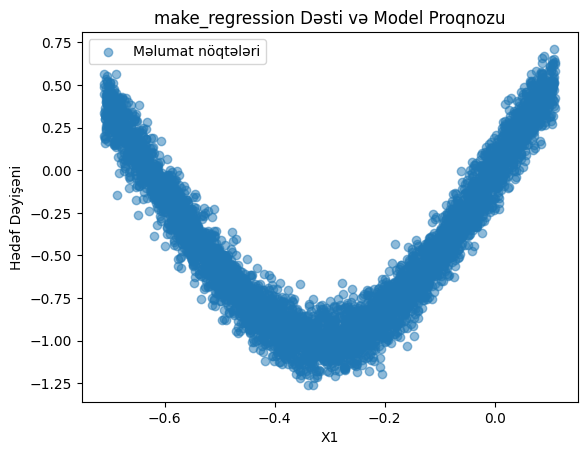

In [117]:
# Qeyri-xətti regression data
np.random.seed(42)
X = np.random.uniform(-0.71,0.11, (5000, 10))
y = np.sin(5 * X[:, 0]) + 0.1 * np.random.randn(5000)

plt.scatter(X[:, 0], y, alpha=0.5, label='Məlumat nöqtələri')
# Daha dəqiq bir vizuallaşdırma üçün səthi çəkmək lazımdır.
plt.xlabel('X1')
plt.ylabel('Hədəf Dəyişəni')
plt.title('make_regression Dəsti və Model Proqnozu')
plt.legend()
plt.show()


#### ƏLLƏ GRADIENT BOOSTING (3 ağac)


In [188]:
print("=" * 50)
print("ƏLLƏ GRADIENT BOOSTING 1 ")
print("=" * 50)

for l in (0.1,0.5 ,1.0):
    tree_reg1 = DecisionTreeRegressor(
                                        max_depth=2,
                                        random_state=42
                                        )
    tree_reg1.fit(X, y)


    y2 = y - l* tree_reg1.predict(X)
    tree_reg2 = DecisionTreeRegressor(
                                        max_depth=2,
                                        random_state=42
                                        )
    tree_reg2.fit(X, y2)


    y3 = y2 - l* tree_reg2.predict(X)
    tree_reg3 = DecisionTreeRegressor(  
                                    max_depth=2,
                                        random_state=42
                                        )
    tree_reg3.fit(X, y3)


    pred = sum(l*tree.predict(X) for tree in (tree_reg1, tree_reg2, tree_reg3))
    print(f"Learning rate = {l},R² score: {r2_score(y, pred):.4f}, MSE: {mean_squared_error(y, pred):.4f}")
    


# ============================================
# 2. ƏLLƏ GRADIENT BOOSTING (3 ağac)
# ============================================
# ==============================
print("=" * 50)
print("ƏLLƏ GRADIENT BOOSTING 2 ")
print("=" * 50)

for  l  in  (0.1,0.5, 1.0):
    pred1 = np.zeros(len(y))  # Başlanğıc proqnoz
    trees = []
    for _ in range(3):
        residuals = y - pred1         # Cari qalıqlar
        tree = DecisionTreeRegressor(
                                    max_depth=2,
                                     random_state=42
                                     )
        tree.fit(X, residuals)       # Qalıqlara öyrət
        pred1 += l* tree.predict(X)      # Proqnozu yenilə
        trees.append(tree)

    test_pred = sum(l * tree.predict(X) for tree in trees)
    print(f"Learning rate = {l}, R² score: {r2_score(y, test_pred):.4f}, MSE: {mean_squared_error(y, test_pred):.4f}")


# ============================================
# SCIKIT-LEARN İLƏ GBRT
# ============================================
# ==============================
print("=" * 50)
print("SCIKIT-LEARN İLƏ GBRT ")
print("=" * 50)
# Fərqli learning rate-lərlə
for lr in (0.1, 0.5, 1.0):
    gbrt = GradientBoostingRegressor(
                                    max_depth=2,
                                      n_estimators=3,
                                        learning_rate=lr,
                                          init='zero',
                                            random_state=42
                                            )
    gbrt.fit(X_train, y_train)
    
    print(f"Learning rate = {lr}, R² score: {r2_score(y_test, gbrt.predict(X_test)):.4f}, MSE: {mean_squared_error(y_test, gbrt.predict(X_test)):.4f}")


ƏLLƏ GRADIENT BOOSTING 1 
Learning rate = 0.1,R² score: -0.2164, MSE: 0.3041
Learning rate = 0.5,R² score: 0.6821, MSE: 0.0795
Learning rate = 1.0,R² score: 0.7149, MSE: 0.0713
ƏLLƏ GRADIENT BOOSTING 2 
Learning rate = 0.1, R² score: -0.2164, MSE: 0.3041
Learning rate = 0.5, R² score: 0.6821, MSE: 0.0795
Learning rate = 1.0, R² score: 0.7149, MSE: 0.0713
SCIKIT-LEARN İLƏ GBRT 
Learning rate = 0.1, R² score: -0.2772, MSE: 0.3186
Learning rate = 0.5, R² score: 0.6870, MSE: 0.0781
Learning rate = 1.0, R² score: 0.7268, MSE: 0.0682


#### OPTIMAL AĞAC SAYINI TAPMAQ (staged_predict)


In [190]:

X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

gbrt = GradientBoostingRegressor(max_depth=2,
                                  n_estimators=120,
                                    random_state=42)
gbrt.fit(X_train_split, y_train_split)

# Validasiya səhvləri
errors = [mean_squared_error(y_val, y_pred) for y_pred in gbrt.staged_predict(X_val)]
best_n_estimators = np.argmin(errors)

# Ən yaxşı model
gbrt_best = GradientBoostingRegressor(max_depth=2,
                                       n_estimators=best_n_estimators,
                                         random_state=42)
gbrt_best.fit(X_train_split, y_train_split)

print(f"Ən yaxşı ağac sayı: {best_n_estimators}")
print(f"Ən aşağı MSE: {errors[best_n_estimators]:.4f}")
print(f"R² score: {r2_score(y_val, gbrt_best.predict(X_val)):.4f}")


Ən yaxşı ağac sayı: 119
Ən aşağı MSE: 0.0528
R² score: 0.7886


####  WARM START İLƏ EARLY STOPPING


In [192]:

gbrt = GradientBoostingRegressor(max_depth=2,
                                  warm_start=True,
                                    random_state=42)
min_val_error = float('inf')
error_going_up = 0

for n_estimators in range(1, 121):
    gbrt.n_estimators = n_estimators
    gbrt.fit(X_train_split, y_train_split)
    y_pred = gbrt.predict(X_val)
    val_error = mean_squared_error(y_val, y_pred)
    
    if val_error < min_val_error:
        min_val_error = val_error
        error_going_up = 0
    else:
        error_going_up += 1
        if error_going_up == 5:
            print(f"Early stopping at n_estimators = {n_estimators}")
            break

y_pred_train = gbrt.predict(X_train_split)
y_pred_val = gbrt.predict(X_val)

print(f'Train MSE: {mean_squared_error(y_train_split, y_pred_train):.4f}')
print(f'Validation MSE: {mean_squared_error(y_val, y_pred_val):.4f}')
print(f'R² Score: {r2_score(y_val, y_pred_val):.4f}')
print(f'Final n_estimators: {gbrt.n_estimators}')


Train MSE: 0.0447
Validation MSE: 0.0528
R² Score: 0.7886
Final n_estimators: 120


#### STOCHASTIC GRADIENT BOOSTING (subsample)

+ 1.0  olduqda   - - Yavas ve __overfitting__ yuksek
+ 0.5  olduqda   --  balansli  
+ 0.25 olduqda   --  Suretli  amma __underfitting__

In [189]:

subsample_values = [1.0, 0.8, 0.5, 0.25]

for sub in subsample_values:
    # Vaxtı ölç
    start = time.time()
    gbrt = GradientBoostingRegressor(
        n_estimators=100, 
        subsample=sub,
        max_depth=2,
        random_state=42
    )
    gbrt.fit(X_train, y_train)
    elapsed_time = time.time() - start
    
    # Performance hesabla
    y_pred_train = gbrt.predict(X_train)
    y_pred_val = gbrt.predict(X_val)
    
    train_mse = mean_squared_error(y_train, y_pred_train)
    val_mse = mean_squared_error(y_val, y_pred_val)
    val_r2 = r2_score(y_val, y_pred_val)
    
    print(f"\nSubsample = {sub:.2f} ({int(sub*100)}% data):")
    print(f"  Vaxt: {elapsed_time:.3f}s")
    print(f"  Train MSE: {train_mse:.4f}")
    print(f"  Val MSE: {val_mse:.4f}")
    print(f"  Val R²: {val_r2:.4f}")


Subsample = 1.00 (100% data):
  Vaxt: 0.276s
  Train MSE: 0.0468
  Val MSE: 0.0494
  Val R²: 0.8024

Subsample = 0.80 (80% data):
  Vaxt: 0.255s
  Train MSE: 0.0468
  Val MSE: 0.0495
  Val R²: 0.8018

Subsample = 0.50 (50% data):
  Vaxt: 0.207s
  Train MSE: 0.0474
  Val MSE: 0.0497
  Val R²: 0.8008

Subsample = 0.25 (25% data):
  Vaxt: 0.152s
  Train MSE: 0.0480
  Val MSE: 0.0500
  Val R²: 0.7999


#### OTHER LOSS FUNCTIONS

In [193]:

# Loss funksiyaları konfiqurasiyası
loss_configs = [
    {'loss': 'squared_error', 'name': 'Squared Error (MSE)', 'params': {}},
    {'loss': 'absolute_error', 'name': 'Absolute Error (MAE)', 'params': {}},
    {'loss': 'huber', 'name': 'Huber', 'params': {'alpha': 0.9}},
    {'loss': 'quantile', 'name': 'Quantile (Median)', 'params': {'alpha': 0.5}},
]

results = []

for config in loss_configs:
    # Model yarat
    params = {
        'loss': config['loss'],
        'n_estimators': 100,
        'max_depth': 3,
        'random_state': 42
    }
    params.update(config['params'])
    
    gbrt = GradientBoostingRegressor(**params)
    gbrt.fit(X_train, y_train)
    
    # Proqnozlar
    y_pred_train = gbrt.predict(X_train)
    y_pred_val = gbrt.predict(X_val)
    
    # Metriklər
    train_mse = mean_squared_error(y_train, y_pred_train)
    val_mse = mean_squared_error(y_val, y_pred_val)
    train_mae = mean_absolute_error(y_train, y_pred_train)
    val_mae = mean_absolute_error(y_val, y_pred_val)
    val_r2 = r2_score(y_val, y_pred_val)
    
    results.append({
        'name': config['name'],
        'loss': config['loss'],
        'train_mse': train_mse,
        'val_mse': val_mse,
        'train_mae': train_mae,
        'val_mae': val_mae,
        'val_r2': val_r2,
        'predictions': y_pred_val
    })
    
    print(f"\n{config['name']}:")
    print(f"  Train MSE: {train_mse:.2f}")
    print(f"  Val MSE:   {val_mse:.2f}")
    print(f"  Train MAE: {train_mae:.2f}")
    print(f"  Val MAE:   {val_mae:.2f}")
    print(f"  Val R²:    {val_r2:.4f}")


Squared Error (MSE):
  Train MSE: 0.04
  Val MSE:   0.04
  Train MAE: 0.10
  Val MAE:   0.11
  Val R²:    0.8400

Absolute Error (MAE):
  Train MSE: 0.49
  Val MSE:   0.48
  Train MAE: 0.49
  Val MAE:   0.48
  Val R²:    -0.9417

Huber:
  Train MSE: 0.04
  Val MSE:   0.05
  Train MAE: 0.10
  Val MAE:   0.10
  Val R²:    0.8135

Quantile (Median):
  Train MSE: 0.49
  Val MSE:   0.48
  Train MAE: 0.49
  Val MAE:   0.48
  Val R²:    -0.9417


### Classifier

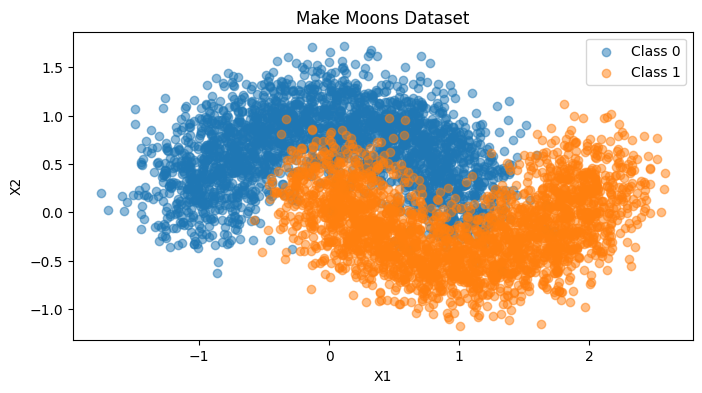

In [143]:
X, y = make_moons(n_samples=5000, noise=0.25, random_state=42)

plt.figure(figsize=(8, 4))
plt.scatter(X[y==0, 0], X[y==0, 1], alpha=0.5, label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], alpha=0.5, label='Class 1')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Make Moons Dataset')
plt.legend()
plt.show()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### ƏLLƏ GRADIENT BOOSTING (3 ağac)


In [144]:
# ============================================
# ============================================
print("=" * 50)
print("ƏLLƏ GRADIENT BOOSTING")
print("=" * 50)

# İlk ağac
tree_clf1 = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf1.fit(X_train, y_train)

# İkinci ağac - ilk ağacın səhvlərinə öyrədilir
y_pred_1 = tree_clf1.predict(X_train)
errors_1 = (y_train != y_pred_1).astype(int)

tree_clf2 = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf2.fit(X_train, errors_1)

# Üçüncü ağac - ikinci ağacın səhvlərinə öyrədilir
y_pred_2 = tree_clf2.predict(X_train)
errors_2 = (errors_1 != y_pred_2).astype(int)

tree_clf3 = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf3.fit(X_train, errors_2)

print(f"İlk ağac accuracy: {accuracy_score(y_test, tree_clf1.predict(X_test)):.4f}")


ƏLLƏ GRADIENT BOOSTING
İlk ağac accuracy: 0.9140


#### SCIKIT-LEARN İLƏ GBRT

In [145]:
# ============================================
# ============================================
print("\n" + "=" * 50)
print("SCIKIT-LEARN İLƏ GRADIENT BOOSTING")
print("=" * 50)

# Sadə model - 3 ağac
gbc = GradientBoostingClassifier(max_depth=2, n_estimators=3, learning_rate=1.0, random_state=42)
gbc.fit(X_train, y_train)

print(f"3 ağaclı model accuracy: {accuracy_score(y_test, gbc.predict(X_test)):.4f}")

# Fərqli learning rate-lərlə
gbc_low = GradientBoostingClassifier(max_depth=2, n_estimators=50, learning_rate=0.1, random_state=42)
gbc_low.fit(X_train, y_train)

gbc_high = GradientBoostingClassifier(max_depth=2, n_estimators=50, learning_rate=1.0, random_state=42)
gbc_high.fit(X_train, y_train)

print(f"\nLearning rate = 0.1, accuracy: {accuracy_score(y_test, gbc_low.predict(X_test)):.4f}")
print(f"Learning rate = 1.0, accuracy: {accuracy_score(y_test, gbc_high.predict(X_test)):.4f}")



SCIKIT-LEARN İLƏ GRADIENT BOOSTING
3 ağaclı model accuracy: 0.9140

Learning rate = 0.1, accuracy: 0.9420
Learning rate = 1.0, accuracy: 0.9380


#### OPTIMAL AĞAC SAYINI TAPMAQ (staged_predict)


OPTIMAL AĞAC SAYINI TAPMAQ
Ən yaxşı ağac sayı: 119
Ən aşağı log loss: 0.1551
Test accuracy: 0.9400


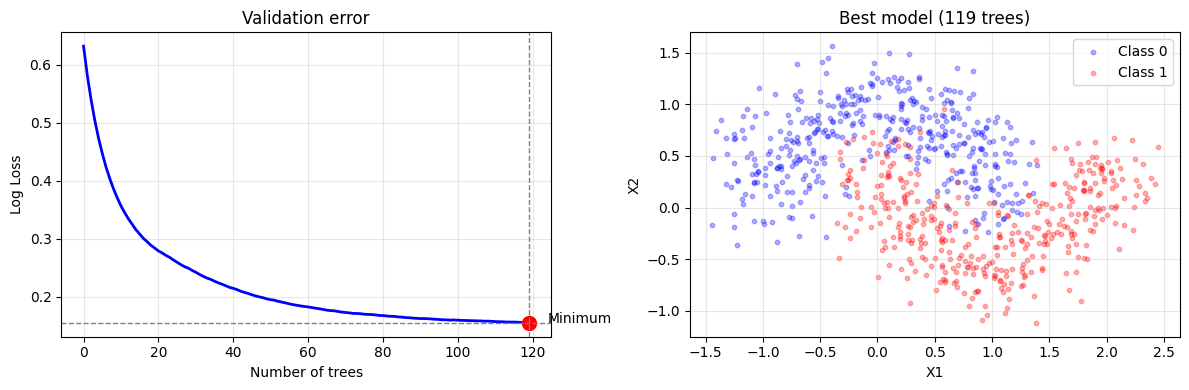

In [146]:

# ============================================
# ============================================
print("\n" + "=" * 50)
print("OPTIMAL AĞAC SAYINI TAPMAQ")
print("=" * 50)

X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

gbc = GradientBoostingClassifier(max_depth=2, n_estimators=120, random_state=42)
gbc.fit(X_train_split, y_train_split)

# Validasiya səhvləri
errors = [log_loss(y_val, y_pred) for y_pred in gbc.staged_predict_proba(X_val)]
best_n_estimators = np.argmin(errors)

# Ən yaxşı model
gbc_best = GradientBoostingClassifier(max_depth=2, n_estimators=best_n_estimators, random_state=42)
gbc_best.fit(X_train_split, y_train_split)

print(f"Ən yaxşı ağac sayı: {best_n_estimators}")
print(f"Ən aşağı log loss: {errors[best_n_estimators]:.4f}")
print(f"Test accuracy: {accuracy_score(y_val, gbc_best.predict(X_val)):.4f}")

# Vizuallaşdırma
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(errors, 'b-', linewidth=2)
plt.plot(best_n_estimators, errors[best_n_estimators], 'ro', markersize=10)
plt.axhline(errors[best_n_estimators], color='gray', linestyle='--', linewidth=1)
plt.axvline(best_n_estimators, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Number of trees')
plt.ylabel('Log Loss')
plt.title('Validation error')
plt.grid(True, alpha=0.3)
plt.text(best_n_estimators + 5, errors[best_n_estimators], 'Minimum')

plt.subplot(1, 2, 2)
y_pred_proba = gbc_best.predict_proba(X_val)[:, 1]
plt.scatter(X_val[y_val==0, 0], X_val[y_val==0, 1], c='blue', alpha=0.3, s=10, label='Class 0')
plt.scatter(X_val[y_val==1, 0], X_val[y_val==1, 1], c='red', alpha=0.3, s=10, label='Class 1')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title(f'Best model ({best_n_estimators} trees)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### WARM START İLƏ EARLY STOPPING


In [147]:
# ============================================
# ============================================
print("\n" + "=" * 50)
print("WARM START İLƏ EARLY STOPPING")
print("=" * 50)

gbc = GradientBoostingClassifier(max_depth=2, warm_start=True, random_state=42)
min_val_error = float('inf')
error_going_up = 0

for n_estimators in range(1, 121):
    gbc.n_estimators = n_estimators
    gbc.fit(X_train_split, y_train_split)
    y_pred = gbc.predict(X_val)
    val_error = log_loss(y_val, gbc.predict_proba(X_val))
    
    if val_error < min_val_error:
        min_val_error = val_error
        error_going_up = 0
    else:
        error_going_up += 1
        if error_going_up == 5:
            print(f"Early stopping at n_estimators = {n_estimators}")
            break

print(f"Final accuracy: {accuracy_score(y_val, gbc.predict(X_val)):.4f}")


WARM START İLƏ EARLY STOPPING
Final accuracy: 0.9400


#### STOCHASTIC GRADIENT BOOSTING (subsample)


In [148]:
# ============================================
# ============================================
print("\n" + "=" * 50)
print("STOCHASTIC GRADIENT BOOSTING")
print("=" * 50)

gbc_full = GradientBoostingClassifier(max_depth=2, n_estimators=100, subsample=1.0, random_state=42)
gbc_sub = GradientBoostingClassifier(max_depth=2, n_estimators=100, subsample=0.5, random_state=42)

gbc_full.fit(X_train_split, y_train_split)
gbc_sub.fit(X_train_split, y_train_split)

print(f"Subsample=1.0, accuracy: {accuracy_score(y_val, gbc_full.predict(X_val)):.4f}")
print(f"Subsample=0.5, accuracy: {accuracy_score(y_val, gbc_sub.predict(X_val)):.4f}")



STOCHASTIC GRADIENT BOOSTING
Subsample=1.0, accuracy: 0.9400
Subsample=0.5, accuracy: 0.9325


#### FƏRQLI LOSS FUNKSIYALARI


In [149]:
# ============================================
# ============================================
print("\n" + "=" * 50)
print("FƏRQLI LOSS FUNKSIYALARI")
print("=" * 50)

gbc_log = GradientBoostingClassifier(max_depth=2, n_estimators=100, loss='log_loss', random_state=42)
gbc_exp = GradientBoostingClassifier(max_depth=2, n_estimators=100, loss='exponential', random_state=42)

gbc_log.fit(X_train_split, y_train_split)
gbc_exp.fit(X_train_split, y_train_split)

print(f"Log Loss: accuracy = {accuracy_score(y_val, gbc_log.predict(X_val)):.4f}")
print(f"Exponential Loss: accuracy = {accuracy_score(y_val, gbc_exp.predict(X_val)):.4f}")

print("\n" + "=" * 50)
print("TAMAMLANDI!")
print("=" * 50)


FƏRQLI LOSS FUNKSIYALARI
Log Loss: accuracy = 0.9400
Exponential Loss: accuracy = 0.9413

TAMAMLANDI!


## Stacking

### Classifier

In [213]:
# model1 = RandomForestClassifier()
# model2 = SVC()
# model3 = KNeighborsClassifier()

# pred1 = model1.fit(X_train,y_train).predict(X_holdout)
# pred2 = model2.fit(X_train,y_train).predict(X_holdout)
# pred3 = model3.fit(X_train,y_train).predict(X_holdout)

# X_blender_train = np.column_stack([pred1,pred2,pred3])

# blender = LogisticRegression()
# blender.fit(X_blender_train,y_holdout)

# new_pred1 = model1.predict(X_new)
# new_pred2 = model2.predict(X_new)
# new_pred3 = model3.predict(X_new)

# X_blender_new = np.column_stack([new_pred1,new_pred2,new_pred3])
# final_prediction = blender.predict(X_blender_new)

In [ ]:
X, y =make_moons(n_samples=10000 , noise=0.3, random_state = 42)
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=3000)

# Baza modellər ( Ferqli  olmalidir)
base_classifiers = [
    ('dt', DecisionTreeClassifier(max_depth=5,
                                   random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=500,
                                   random_state=42)),
    ('svc', SVC( probability=True,
                 random_state=42))
]

# Meta model  ( SADE OLMALIDIR ! )
meta_classifier = LogisticRegression()

# Stacking
stacking_clf = StackingClassifier( estimators= base_classifiers,
                                  final_estimator= meta_classifier,
                                  cv=5
)

stacking_clf.fit(X_train, y_train)
y_pred = stacking_clf.predict(X_test)

print(f"Stacking Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Fərdi modellərlə müqayisə
print("\nFərdi modellər:")
for name, model in base_classifiers:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"{name.upper()} Accuracy: {accuracy_score(y_test, pred):.4f}")



Stacking Accuracy: 0.9207

Fərdi modellər:
DT Accuracy: 0.9017
RF Accuracy: 0.9077
SVC Accuracy: 0.9220


### Reqressor

In [240]:
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target  
  
X_train, X_test, y_train, y_test = train_test_split(X,
                                                     y,
                                                       test_size=0.2,
                                                         random_state=42)

# Baza modellər (birinci qat)
base_models = [
    ('dt', DecisionTreeRegressor(max_depth=5,
                                  random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=500,
                                  random_state=42)),
    ('svr', SVR(kernel='rbf'))
]

# Meta model (ikinci qat - blender)
meta_model = LinearRegression()

# Stacking
stacking_reg = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5  # Cross-validation
)

stacking_reg.fit(X_train, y_train)
y_pred = stacking_reg.predict(X_test)

print(f"Stacking R²: {r2_score(y_test, y_pred):.4f}")
print(f"Stacking MSE: {mean_squared_error(y_test, y_pred):.4f}")

# Fərdi modellərlə müqayisə
print("\nFərdi modellər:")
for name, model in base_models:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"{name.upper()} R²: {r2_score(y_test, pred):.4f}")
    print(f"{name.upper()} MSE: {mean_squared_error(y_test, pred):.0f}")

Stacking R²: 0.4558
Stacking MSE: 2883.4205

Fərdi modellər:
DT R²: 0.3345
DT MSE: 3526
RF R²: 0.4350
RF MSE: 2993
SVR R²: 0.1821
SVR MSE: 4333
